C:\Users\levyrios-ieg\AppData\Local\Temp\ipykernel_45876\964856236.py:21: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['retorno_pct'] = df['VALUE'].pct_change() * 100


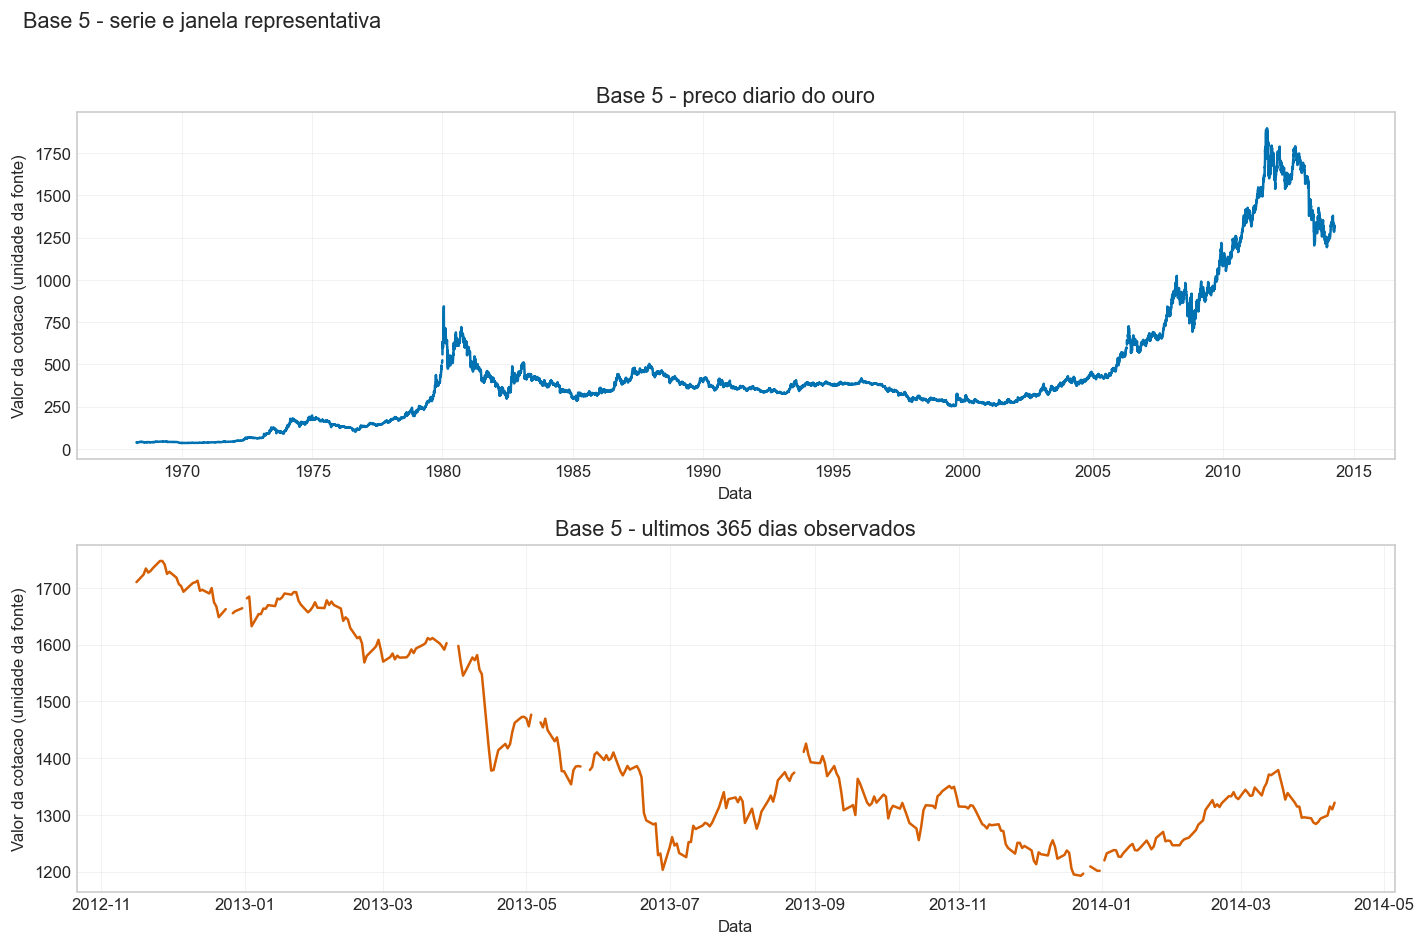

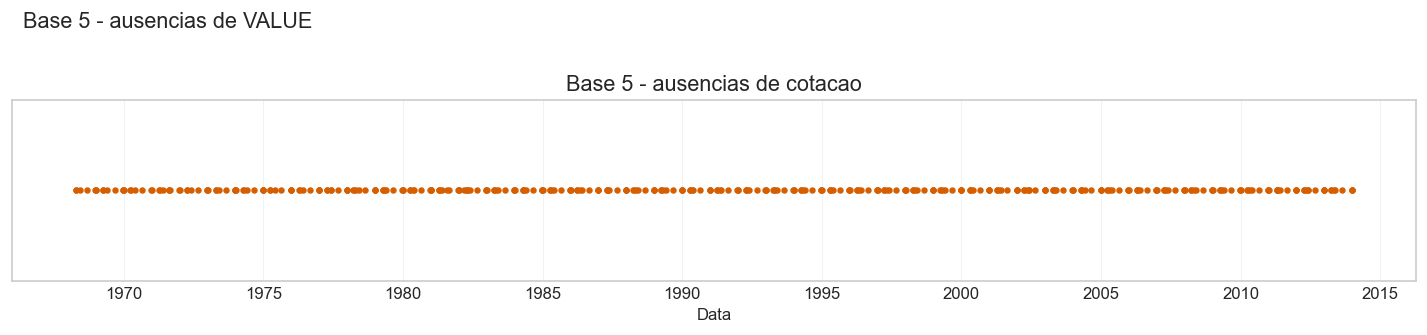

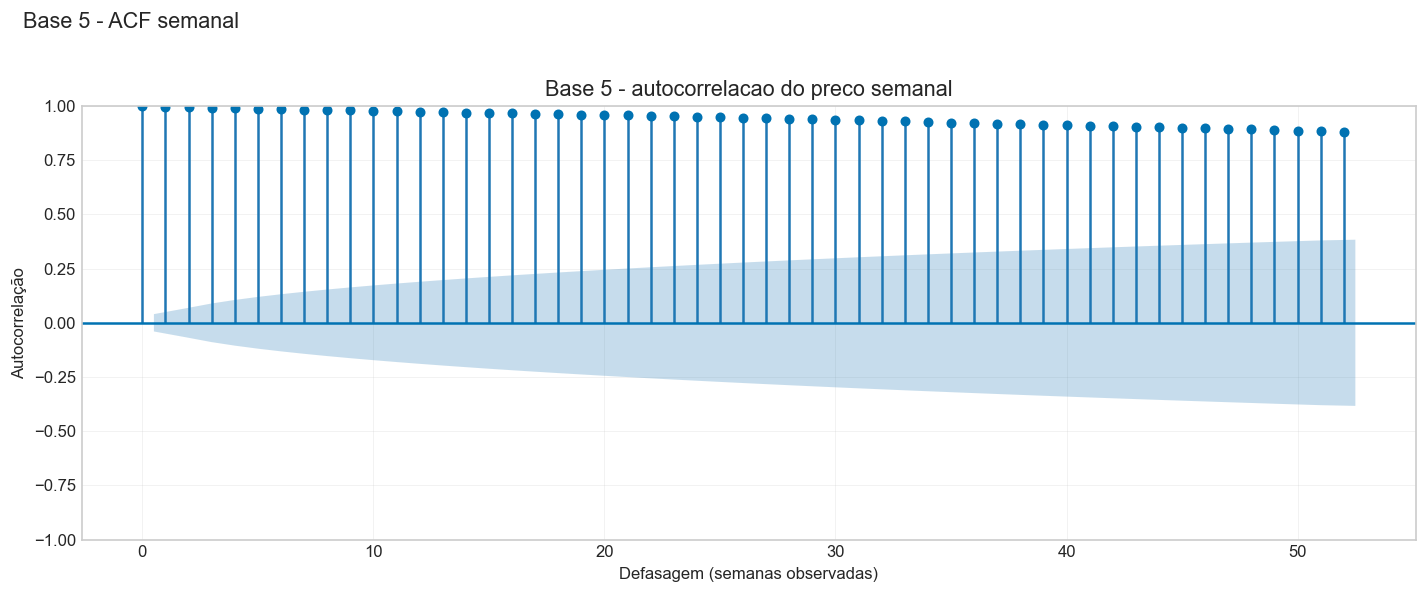

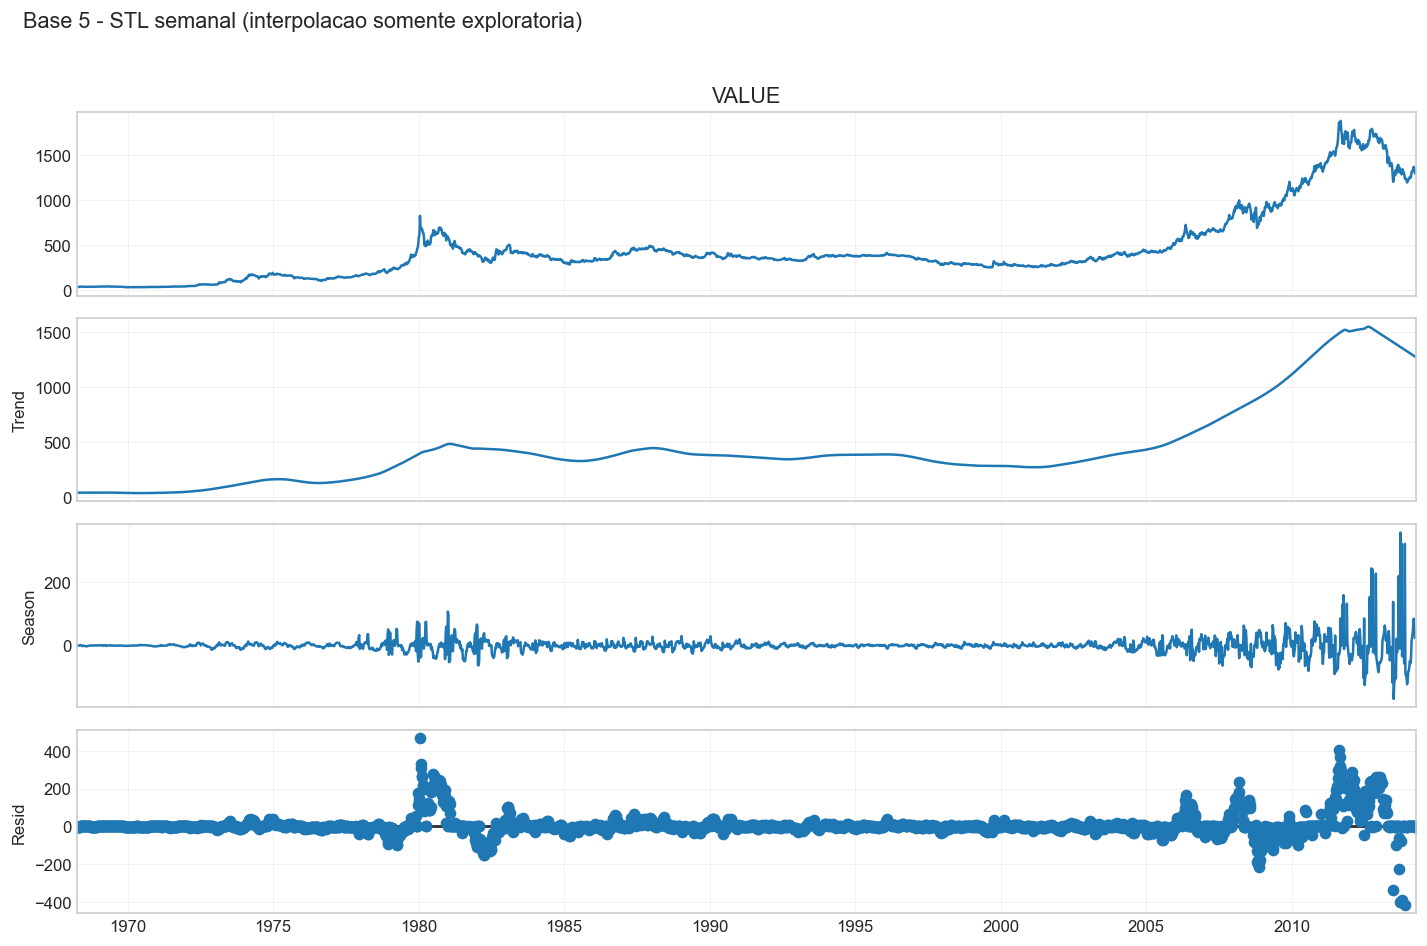

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from series_temporais.reporting.graficos_exploratorios import PALETA, aplicar_estilo, finalizar_figura, plotar_acf

aplicar_estilo()
DATA_PATH = ROOT / 'trabalho/bases/grupo5/grupo5_new.csv'
FIG_DIR = ROOT / 'docs/revisoes/graficos/base5'
df = pd.read_csv(DATA_PATH, sep=';', parse_dates=['DATE'])
df['VALUE'] = pd.to_numeric(df['VALUE'], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
assert df.columns.tolist() == ['DATE', 'VALUE', 'IS_HOLIDAY', 'TARGET_UP']
df['retorno_pct'] = df['VALUE'].pct_change() * 100
df['semana'] = df['DATE'].dt.to_period('W-FRI').dt.end_time.dt.normalize()
weekly = df.groupby('semana', as_index=False)['VALUE'].last()
regular = weekly.set_index('semana')['VALUE'].asfreq('W-FRI')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(df['DATE'], df['VALUE'], color=PALETA['serie'])
axes[0].set(title='Base 5 - preco diario do ouro', xlabel='Data', ylabel='Valor da cotacao (unidade da fonte)')
recent = df.tail(365)
axes[1].plot(recent['DATE'], recent['VALUE'], color=PALETA['secundaria'])
axes[1].set(title='Base 5 - ultimos 365 dias observados', xlabel='Data', ylabel='Valor da cotacao (unidade da fonte)')
finalizar_figura(fig, 'Base 5 - serie e janela representativa', FIG_DIR / 'serie_e_janela.png')
plt.show()

missing = df['VALUE'].isna()
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.scatter(df.loc[missing, 'DATE'], np.ones(missing.sum()), s=8, color=PALETA['ausencia'])
ax.set(title='Base 5 - ausencias de cotacao', xlabel='Data', yticks=[])
finalizar_figura(fig, 'Base 5 - ausencias de VALUE', FIG_DIR / 'ausencias.png')
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
observed = regular.dropna()
plotar_acf(ax, observed.to_numpy(), lags=min(52, len(observed) - 2), unidade='semanas observadas')
ax.set_title('Base 5 - autocorrelacao do preco semanal')
finalizar_figura(fig, 'Base 5 - ACF semanal', FIG_DIR / 'acf_semanal.png')
plt.show()

stl_series = regular.interpolate(method='time', limit_direction='both')
result = STL(stl_series, period=52, robust=True).fit()
fig = result.plot()
fig.set_size_inches(12, 8)
finalizar_figura(fig, 'Base 5 - STL semanal (interpolacao somente exploratoria)', FIG_DIR / 'stl_semanal.png')
plt.show()